# Kassojen käyttöasteen analyysi
Tässä muistikirjassa analysoidaan puhtaasta datasta (`data/processed/*.parquet`) kassojen käyttöastetta perustuen `store_config.py`-tiedostossa määriteltyihin koordinaatteihin.

In [4]:
import sys
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lisätään projektin juurikansio polkuun
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from config.store_config import store_config


In [5]:
# Luodaan DuckDB-yhteys muistiin
con = duckdb.connect(':memory:')

# Luetaan kassojen koordinaatit asetustiedostosta
checkouts = store_config["spatial_zones"]["checkouts"]

# Muodostetaan SQL-lauseke, jolla asioinnit kohdistetaan eri kassoille
case_statements = []
for kassa_nimi, data in checkouts.items():
    x_min, x_max, y_min, y_max = data["coords"]
    case_statements.append(f"WHEN x BETWEEN {x_min} AND {x_max} AND y BETWEEN {y_min} AND {y_max} THEN '{kassa_nimi}'")

case_sql = " ".join(case_statements)

# Kysely laskee yksittäisten asiointien (final_sid) määrän kassan alueella. Käytetään '../data/processed/*.parquet'
query = f"""
SELECT 
    CASE 
        {case_sql}
        ELSE 'Muu / Ei kassalla'
    END AS kassa,
    COUNT(DISTINCT final_sid) as asiointien_maara
FROM read_parquet('../data/processed/*.parquet')
WHERE x BETWEEN -200 AND 700 AND y BETWEEN 0 AND 2000
GROUP BY kassa
HAVING kassa != 'Muu / Ei kassalla'
ORDER BY kassa
"""

# Suoritetaan kysely ja tallennetaan tulos DataFrameen
try:
    df_kassat = con.execute(query).df()
    display(df_kassat)
except Exception as e:
    print("Virhe datan lukemisessa tai kyselyssä:", e)


,kassa,asiointien_maara
0,Kassa 1,2768
1,Kassa 2,4212
2,Kassa 3,4410
3,Kassa 4,3100
4,Kassa 5,2069
5,Kassa 6,1526
6,Kassa 7,1212
7,Kassa 8,415


# Tulosten visualisointi

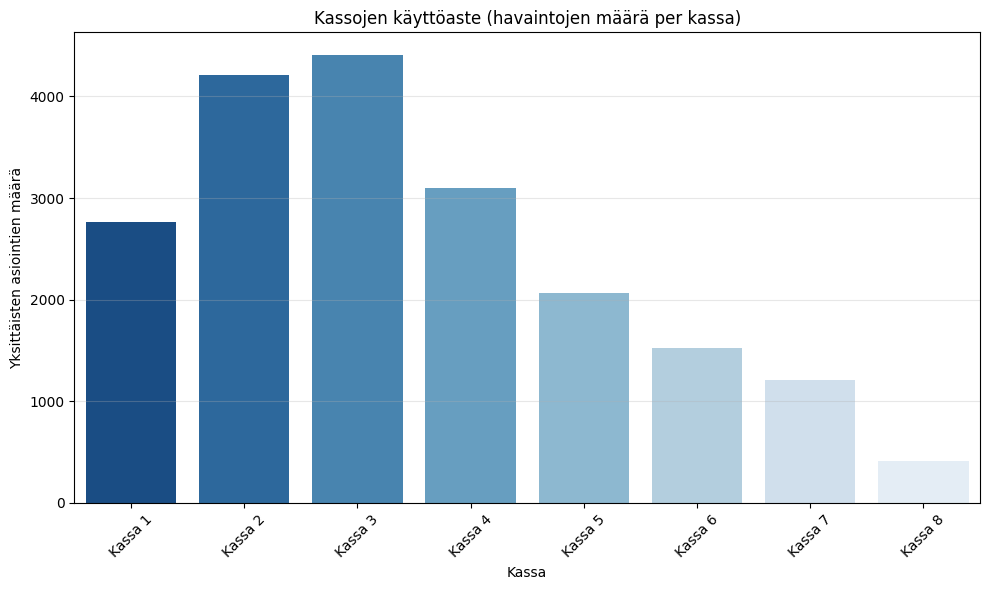

In [6]:
try:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_kassat, x='kassa', y='asiointien_maara', hue='kassa', palette='Blues_r', legend=False)
    plt.title('Kassojen käyttöaste (havaintojen määrä per kassa)')
    plt.xlabel('Kassa')
    plt.ylabel('Yksittäisten asiointien määrä')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Ei voitu luoda kuvaajaa:", e)
